<a href="https://colab.research.google.com/github/SagarEGme/AI-ML/blob/main/fineTbert.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install transformers datasets torch scikit-learn imbalanced-learn nltk seaborn matplotlib pandas

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from transformers import BertForSequenceClassification,BertTokenizer,Trainer, TrainingArguments
import torch
from sklearn.metrics import classification_report,confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from torch.utils.data import DataLoader
from datasets import Dataset

In [ ]:
data = pd.read_csv("/content/sample_data/Combined Data.csv")
data = data.drop(columns=['Unnamed: 0'])
data.dropna(inplace = True)
data.head()

,statement,status
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,I've shifted my focus to something else but I'...,Anxiety
4,"I'm restless and restless, it's been a month n...",Anxiety


In [ ]:
data.shape

(52681, 2)

In [ ]:
data = data.sample(n=6000).reset_index(drop=True)
data.head()

,statement,status
0,Chronic stress recovery from inflammation time...,Stress
1,the cat doesn't care about your homework.,Normal
2,I had to refill it yesterday and took it late ...,Suicidal
3,gift makoti depression yama teki,Depression
4,"For the record, I am not suicidal and I never ...",Suicidal


Text preprocessing


In [ ]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download("stopwords")

stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
def clean_statement(statement):
  statement = statement.lower()
  statement = re.sub(r'[^\w\s]','',statement) #removes punc and sp characters
  statement = re.sub(r'\d+','',statement) # removes numbers
  words = statement.split()
  words = [word for word in words if word not in stop_words]
  cleaned_statement = ' '.join(words)
  return cleaned_statement

#After cleaning
data['statement'] = data['statement'].apply(clean_statement)

In [ ]:
#check status distribution
data['status'].value_counts()

,count
status,
Normal,1874
Depression,1706
Suicidal,1209
Anxiety,482
Bipolar,324
Stress,298
Personality disorder,107


In [ ]:
#Oversampling
from imblearn.over_sampling import RandomOverSampler
ros = RandomOverSampler(sampling_strategy = 'auto',random_state = 42)
X = data.drop(columns=['status'])
y = data['status']

X_resampled,y_resampled = ros.fit_resample(X,y)

#combine back
data = pd.concat([X_resampled,y_resampled],axis=1)

In [ ]:
#Label Encoding
label_encoder = LabelEncoder()
data['label'] = label_encoder.fit_transform(data['status'])

data.head()

,statement,status,label
0,chronic stress recovery inflammation time fram...,Stress,5
1,cat doesnt care homework,Normal,3
2,refill yesterday took late today feel like shi...,Suicidal,6
3,gift makoti depression yama teki,Depression,2
4,record suicidal never going tell something tru...,Suicidal,6


In [ ]:
#Train test split
train_texts, test_texts, train_labels, test_labels = train_test_split(
    data['statement'],
    data['label'],
    test_size=0.2
)
max([len(text) for text in data['statement']])

7176

In [ ]:
#Tokenization using BERT tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

train_encodings = tokenizer(
    list(train_texts),
    padding=True,
    truncation=True,
    max_length = 200
)

test_encodings = tokenizer(
    list(test_texts),
    padding=True,
    truncation=True,
    max_length=200
)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Convert to hugging face dataset format


In [ ]:
train_dataset = Dataset.from_dict({
    'input_ids' : train_encodings['input_ids'],
    'attention_mask' : train_encodings['attention_mask'],
    'labels': train_labels.tolist()
})

test_dataset = Dataset.from_dict({
    'input_ids': test_encodings['input_ids'],
    'attention_mask': test_encodings['attention_mask'],
    'labels': test_labels.tolist()
})

In [ ]:
#Initialize BERT model
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels = len(label_encoder.classes_)
)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
#training arguments
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=10,
    load_best_model_at_end=True,
)

#trainer setup
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset = train_dataset,
    eval_dataset = test_dataset,
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
#train model
trainer.train()

Epoch,Training Loss,Validation Loss
1,0.345281,0.436262
2,0.177560,0.309715
3,0.104618,0.309314


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=1968, training_loss=0.40832268894930196, metrics={'train_runtime': 1290.0751, 'train_samples_per_second': 24.403, 'train_steps_per_second': 1.525, 'total_flos': 3235794572340000.0, 'train_loss': 0.40832268894930196, 'epoch': 3.0})

In [ ]:
#evaluate model
results = trainer.evaluate()
print(results)


{'eval_loss': 0.3093143701553345, 'eval_runtime': 32.1579, 'eval_samples_per_second': 81.597, 'eval_steps_per_second': 5.1, 'epoch': 3.0}


In [ ]:
#prediction
predictions = trainer.predict(test_dataset)
preds = np.argmax(predictions.predictions,axis = 1)

#classification report
print(classification_report(test_labels,preds))

#confusion matrix
cm = confusion_matrix(test_labels,preds)


              precision    recall  f1-score   support

           0       0.95      0.97      0.96       386
           1       0.97      0.97      0.97       354
           2       0.80      0.71      0.76       357
           3       0.94      0.90      0.92       399
           4       0.98      1.00      0.99       387
           5       0.93      0.99      0.96       356
           6       0.80      0.83      0.81       385

    accuracy                           0.91      2624
   macro avg       0.91      0.91      0.91      2624
weighted avg       0.91      0.91      0.91      2624



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


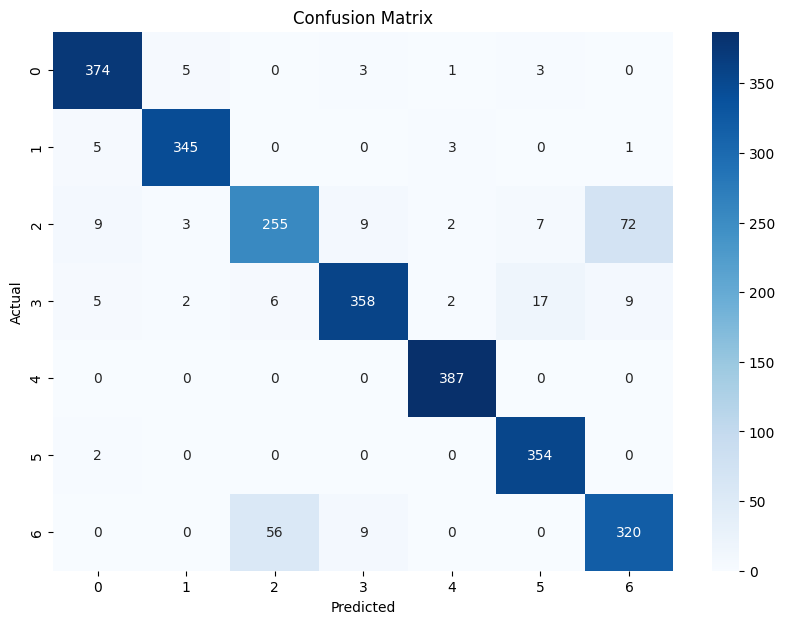

In [ ]:
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
#save and load model
trainer.save_model("/content/drive/MyDrive/fine_tuned_bert")
tokenizer.save_pretrained("/content/drive/MyDrive/fine_tuned_bert")

import pickle

pickle.dump(label_encoder,open('/content/drive/MyDrive/label_encoder.pkl','wb'))

from transformers import AutoModelForSequenceClassification, AutoTokenizer

#now load
model = AutoModelForSequenceClassification.from_pretrained("/content/drive/MyDrive/fine_tuned_bert")
tokenizer = AutoTokenizer.from_pretrained('/content/drive/MyDrive/fine_tuned_bert')

label_encoder = pickle.load(open('/content/drive/MyDrive/label_encoder.pkl','rb'))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [ ]:
#detection
def detection(text):
  text = clean_statement(text)
  inputs = tokenizer(text,return_tensors='pt',padding=True,truncation=True,max_length=200)
  outputs = model(**inputs)
  logits = outputs.logits
  predicted_label = torch.argmax(logits,dim=1).item()

  return label_encoder.inverse_transform([predicted_label])[0]

text = 'i am feeling deeply broken sad , i just failed my examinations'
detection(text)

'Suicidal'